In [1]:
import pandas as pd


In [2]:
notas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/ratings.csv")
notas

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [3]:
notas.shape

(100836, 4)

In [4]:
notas.columns = ["usuarioId", "filmesID", "nota", "momento"]
notas.head()


,usuarioId,filmesID,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
notas["nota"].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [6]:
notas["nota"].value_counts()

,count
nota,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


In [7]:
notas["nota"].mean()

np.float64(3.501556983616962)

<Axes: ylabel='Frequency'>

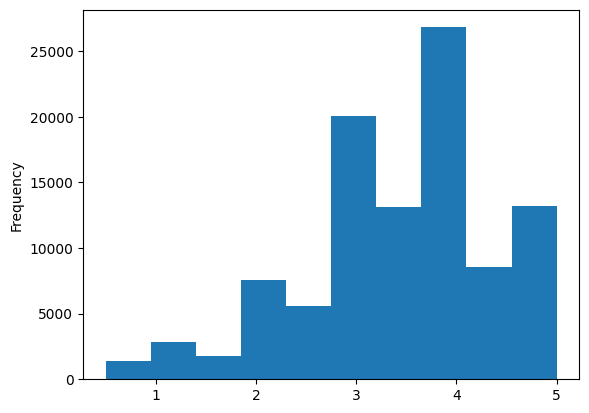

In [8]:
notas["nota"].plot(kind='hist')

In [9]:
notas["nota"].median()


3.5

In [10]:
mediana = notas["nota"].median()
media = notas["nota"].mean()
print(f"Mediana é {mediana}")
print(f"Média é {media}")

Mediana é 3.5
Média é 3.501556983616962


In [11]:
notas["nota"].describe()

,nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


<Axes: ylabel='nota'>

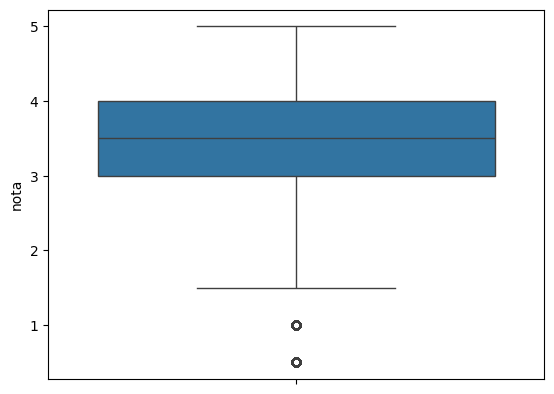

In [12]:
import seaborn as sns

sns.boxplot(notas["nota"])

In [13]:
movies = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/movies.csv")
movies.columns = ["filmesID", "titulo", "generos"]
movies.head()


,filmesID,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [14]:
notas.query("filmesID==1")["nota"].mean()

np.float64(3.9209302325581397)

In [15]:
notas.query("filmesID==2")["nota"].mean()

np.float64(3.4318181818181817)

In [16]:
medias_por_filme = notas.groupby("filmesID")["nota"].mean()
medias_por_filme.head()

,nota
filmesID,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


<Axes: ylabel='Frequency'>

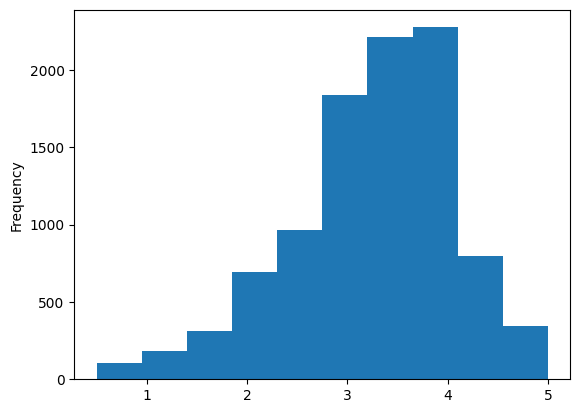

In [17]:
medias_por_filme.plot(kind="hist")

<Axes: ylabel='nota'>

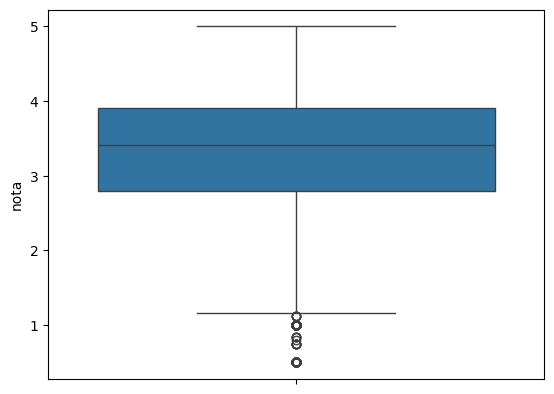

In [18]:
sns.boxplot(medias_por_filme)

In [19]:
medias_por_filme.describe()

,nota
count,9724.000000
mean,3.262448
std,0.869874
min,0.500000
25%,2.800000
50%,3.416667
75%,3.911765
max,5.000000


Text(0.5, 1.0, 'Histograma das médias dos filmes')

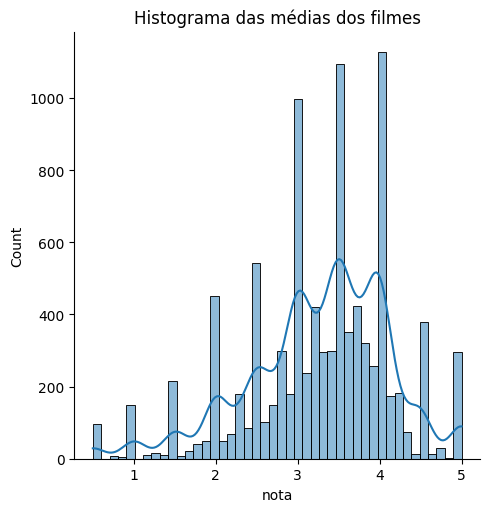

In [20]:
import matplotlib.pyplot as plt

sns.displot(medias_por_filme, kde=True)
plt.title("Histograma das médias dos filmes")


In [21]:
tmdb = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/tmdb_5000_movies.csv")


In [22]:
tmdb.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


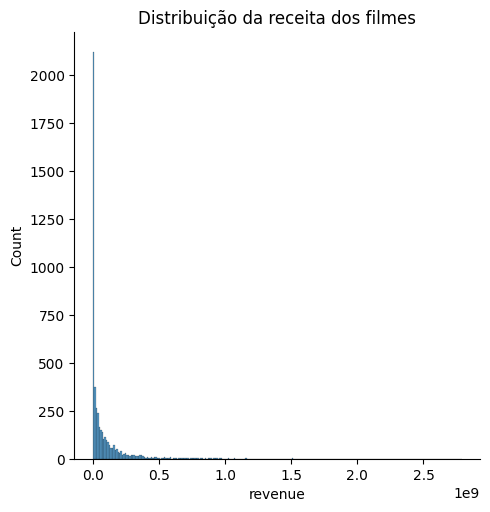

In [23]:
sns.displot(tmdb["revenue"])
plt.title("Distribuição da receita dos filmes")
plt.show()

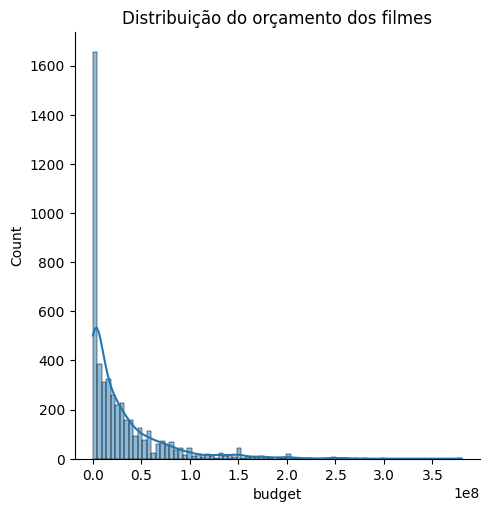

In [24]:
sns.displot(tmdb["budget"], kde=True)
plt.title("Distribuição do orçamento dos filmes")
plt.show()

In [25]:
tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

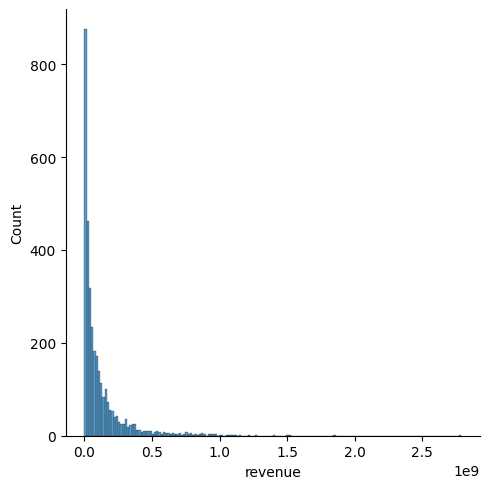

In [26]:
com_faturamento = tmdb.query("revenue > 0")
sns.displot(com_faturamento["revenue"])

In [27]:
tmdb["original_language"].unique()


array(['en', 'ja', 'fr', 'zh', 'es', 'de', 'hi', 'ru', 'ko', 'te', 'cn',
       'it', 'nl', 'ta', 'sv', 'th', 'da', 'xx', 'hu', 'cs', 'pt', 'is',
       'tr', 'nb', 'af', 'pl', 'he', 'ar', 'vi', 'ky', 'id', 'ro', 'fa',
       'no', 'sl', 'ps', 'el'], dtype=object)

In [28]:
tmdb["original_language"].value_counts()

,count
original_language,
en,4505
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
cn,12


In [29]:
# lingua => categorica... sem ordem...

# budget (orçamento) => quantitativa continua


In [30]:
# nota do movielens => 0.5, 1, 1.5 ,,,,,, ,5 => nao tem 2.5
# quantidade de votos => 1,2,3,4,5... nao existe 2.5

In [31]:
tmdb["original_language"].value_counts().index

Index(['en', 'fr', 'es', 'zh', 'de', 'hi', 'ja', 'it', 'cn', 'ko', 'ru', 'pt',
       'da', 'sv', 'nl', 'fa', 'th', 'he', 'id', 'cs', 'ta', 'ro', 'ar', 'te',
       'hu', 'xx', 'af', 'is', 'tr', 'vi', 'pl', 'nb', 'ky', 'no', 'sl', 'ps',
       'el'],
      dtype='object', name='original_language')

In [32]:
tmdb["original_language"].value_counts().values

array([4505,   70,   32,   27,   27,   19,   16,   14,   12,   11,   11,
          9,    7,    5,    4,    4,    3,    3,    2,    2,    2,    2,
          2,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1])

In [33]:
contagem_de_lingua = tmdb["original_language"].value_counts().to_frame().reset_index()
contagem_de_lingua.columns = ["original_language", "total"]
contagem_de_lingua.head()

,original_language,total
0,en,4505
1,fr,70
2,es,32
3,zh,27
4,de,27


<Axes: >

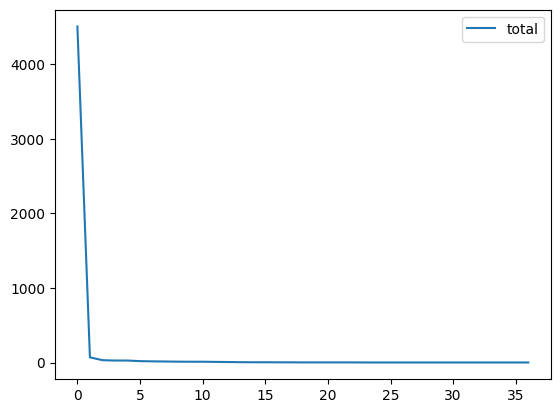

In [34]:
contagem_de_lingua.plot()

<Axes: xlabel='original_language', ylabel='total'>

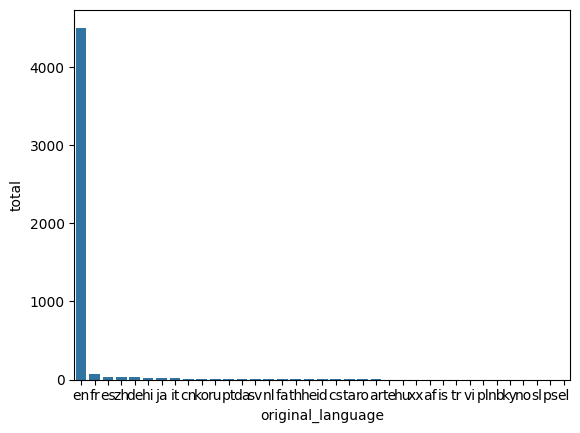

In [35]:
sns.barplot(data = contagem_de_lingua, x="original_language", y= "total")

<Axes: xlabel='original_language', ylabel='count'>

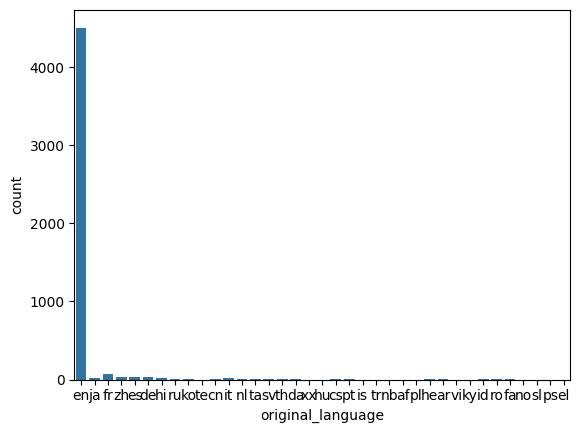

In [36]:
sns.countplot(data = tmdb, x="original_language")

In [37]:
total_por_lingua = tmdb["original_language"].value_counts()
total_geral = total_por_lingua.sum()
total_de_ingles = total_por_lingua.loc["en"]
total_do_resto = total_geral - total_de_ingles
print(total_geral, total_de_ingles, total_do_resto)

4803 4505 298


In [38]:
dados = pd.DataFrame({
    "lingua": ["ingles", "outros"],
    "total": [total_de_ingles, total_do_resto]
})
dados

,lingua,total
0,ingles,4505
1,outros,298


Index(['lingua', 'total'], dtype='object')


<Axes: xlabel='lingua', ylabel='total'>

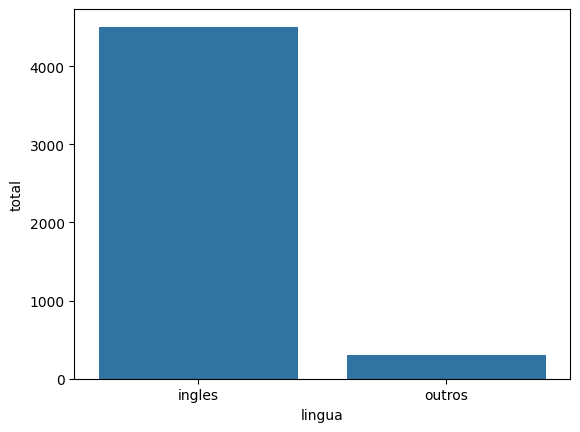

In [39]:
print(dados.columns)
sns.barplot(data=dados, x="lingua", y="total")

<Axes: ylabel='total'>

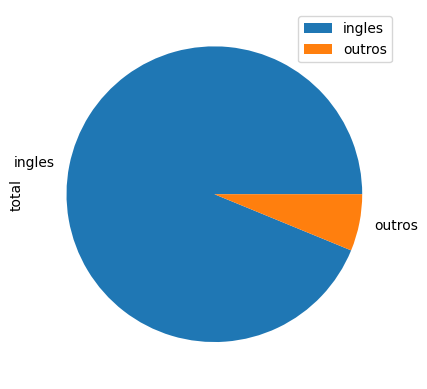

In [40]:
dados.plot(kind="pie", y="total", labels=dados["lingua"])

In [41]:
total_de_outros_filmes_por_lingua = tmdb.query("original_language != 'en'")["original_language"].value_counts()
total_de_outros_filmes_por_lingua.head()

,count
original_language,
fr,70
es,32
zh,27
de,27
hi,19


<Axes: xlabel='original_language', ylabel='count'>

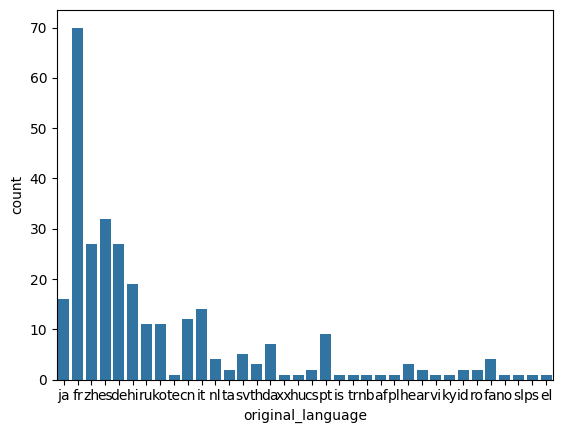

In [42]:
sns.countplot(data=tmdb.query("original_language != 'en'"),
              x="original_language")

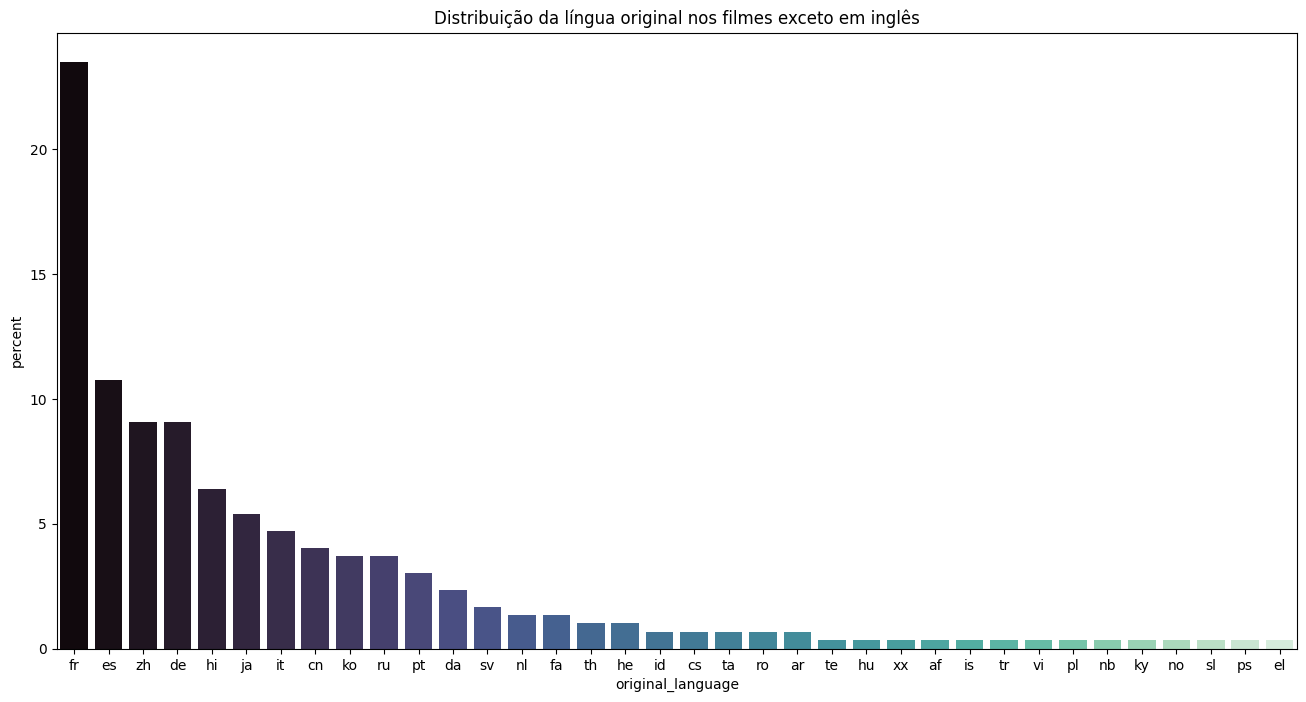

In [43]:
plt.figure(figsize=(16,8))
sns.countplot(data=tmdb.query("original_language != 'en'"),
              order=total_de_outros_filmes_por_lingua.index,
              palette="mako",
              hue="original_language",
              hue_order=total_de_outros_filmes_por_lingua.index,
              stat="percent",
              x="original_language")
plt.title("Distribuição da língua original nos filmes exceto em inglês")
plt.show()

In [44]:
movies.head(2)

,filmesID,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy


In [45]:
nota_filme_1 = medias_por_filme.loc[1]
nota_filme_2 = medias_por_filme.loc[2]

print(f"A nota média do filme com ID 1 é: {nota_filme_1:.2f}")
print(f"A nota média do filme com ID 2 é: {nota_filme_2:.2f}")

A nota média do filme com ID 1 é: 3.92
A nota média do filme com ID 2 é: 3.43


In [46]:
print(f"A mediana das notas é: {mediana}")

A mediana das notas é: 3.5


In [47]:
import numpy as np

filme1 = [2.5] *10 + [3.5] * 10
np.mean(filme1)


np.float64(3.0)

In [48]:
filme2 = [5] * 10 + [1] * 10
np.mean(filme2)

np.float64(3.0)

In [49]:
print(f"Média do filme 1: {np.mean(filme1):.2f}")
print(f"Mediana do filme 1: {np.median(filme1):.2f}")
print(f"Média do filme 2: {np.mean(filme2):.2f}")
print(f"Mediana do filme 2: {np.median(filme2):.2f}")

Média do filme 1: 3.00
Mediana do filme 1: 3.00
Média do filme 2: 3.00
Mediana do filme 2: 3.00


(array([10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

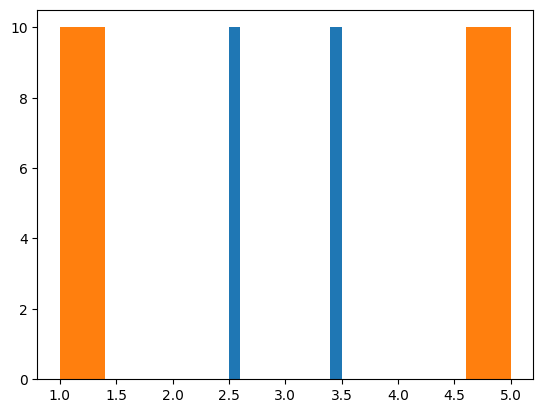

In [50]:
plt.hist(filme1)
plt.hist(filme2)

{'whiskers': [<matplotlib.lines.Line2D at 0x7db8291ad9a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7db8291addc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7db8291ad6d0>,
 'medians': [<matplotlib.lines.Line2D at 0x7db8291ae3c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7db8291ae6c0>,
 'means': []}

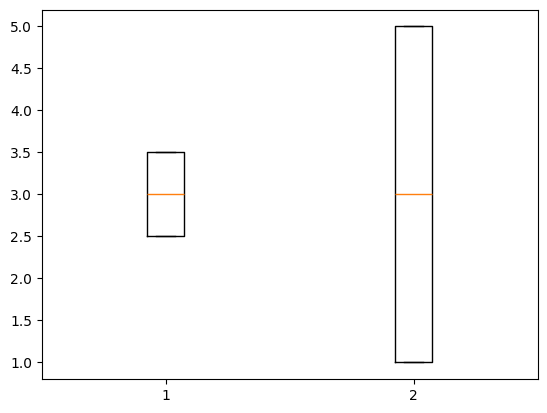

In [51]:
plt.boxplot([filme1,filme2])

In [52]:
filme0 = [3.0] * 20
np.mean(filme0)

np.float64(3.0)

In [53]:
np.std(filme0), np.std(filme1), np.std(filme2)

(np.float64(0.0), np.float64(0.5), np.float64(2.0))

In [54]:
import pandas as pd
import numpy as np

# Criando DataFrame de exemplo

dados = np.array([[100, 120, 90, 110, 130], [80, 150, 70, 140, 60]])

df = pd.DataFrame(dados, index = ["Semana 1", "Semana 2"],
                  columns= ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"])

# Calculando o desvio padrão das visitas por semana
desvio_padrao_semana1 = df.loc["Semana 1"].std()
desvio_padrao_semana2 = df.loc["Semana 2"].std()

print(df)
print("\nDesvio Padrão da Semana 1:", round(desvio_padrao_semana1, 2))
print("Desvio Padrão da Semana 2:", round(desvio_padrao_semana2, 2))

          Segunda  Terça  Quarta  Quinta  Sexta
Semana 1      100    120      90     110    130
Semana 2       80    150      70     140     60

Desvio Padrão da Semana 1: 15.81
Desvio Padrão da Semana 2: 41.83


{'whiskers': [<matplotlib.lines.Line2D at 0x7db82a1f9ca0>,
 'caps': [<matplotlib.lines.Line2D at 0x7db829a22630>,
 'boxes': [<matplotlib.lines.Line2D at 0x7db82a34d2b0>,
 'medians': [<matplotlib.lines.Line2D at 0x7db82a1d5310>,
 'fliers': [<matplotlib.lines.Line2D at 0x7db828384500>,
 'means': []}

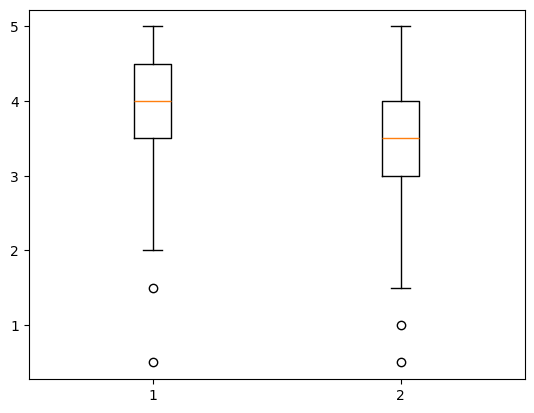

In [58]:
notas_do_toy_story = notas.query("filmesID==1")["nota"]
notas_do_jumanji = notas.query("filmesID==2")["nota"]

plt.boxplot([notas_do_toy_story, notas_do_jumanji])

/tmp/ipykernel_599/1844161106.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=notas.query("filmesID in [1,2,3,4,5]"),


<Axes: xlabel='filmesID', ylabel='nota'>

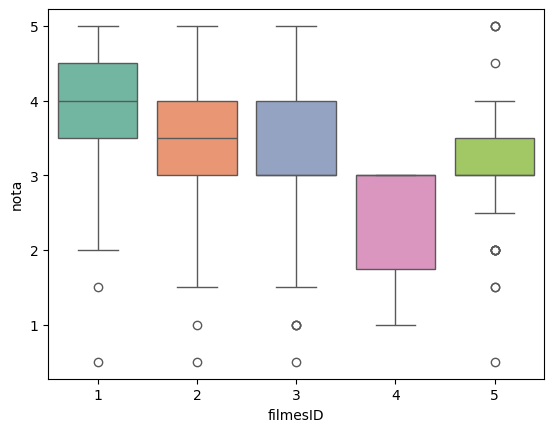

In [64]:
sns.boxplot(data=notas.query("filmesID in [1,2,3,4,5]"),
            x="filmesID",
            y="nota",
            palette="Set2")

In [68]:
notas.groupby("filmesID").count()

,usuarioId,nota,momento
filmesID,,,
1,215,215,215
2,110,110,110
3,52,52,52
4,7,7,7
5,49,49,49
...,...,...,...
193581,1,1,1
193583,1,1,1
193585,1,1,1


In [69]:
notas["filmesID"].value_counts().tail()

,count
filmesID,
188833,1
189381,1
3899,1
2848,1
147002,1


In [71]:
notas.groupby("filmesID").count().query("nota == 1")

,usuarioId,nota,momento
filmesID,,,
49,1,1,1
55,1,1,1
77,1,1,1
83,1,1,1
96,1,1,1
...,...,...,...
193581,1,1,1
193583,1,1,1
193585,1,1,1
